# Sports League Optimization

In [323]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from copy import deepcopy
from abc import ABC, abstractmethod
from copy import deepcopy

### Import Dataset

In [324]:
players_df = pd.read_csv("players(in).csv")

### Initialize

In [325]:
POSITIONS = ["GK", "DEF", "MID", "FWD"]
TEAM_STRUCTURE = {"GK": 1, "DEF": 2, "MID": 2, "FWD": 2}
TEAM_SIZE = 7
N_TEAMS = 5
MAX_BUDGET = 750

### Class Solution

In [326]:
class Solution(ABC):
    def __init__(self, repr=None):
        if repr is None:
            repr = self.random_initial_representation()
        self.repr = repr

    def __repr__(self):
        return str(self.repr)

    @abstractmethod
    def fitness(self):
        pass

    @abstractmethod
    def random_initial_representation(self):
        pass

### Class Team (part of solution)

In [327]:
class Team:
    def __init__(self, players):
        self.players = players

    def is_valid(self):
        pos_count = {p: 0 for p in POSITIONS} #count players in each pos (start w/ 0)
        total_cost = 0
        for player in self.players:
            pos_count[player['Position']] += 1 #when a player is seen sums to the count
            total_cost += player['Salary (€M)'] #and sums their salary
        if any(pos_count[p] != TEAM_STRUCTURE[p] for p in POSITIONS):
            return False  #if any pos doesn't have exacly the right nº of players, its invalid
        if total_cost > MAX_BUDGET:
            return False  #if exceeds the budget, its false
        return True

    def average_skill(self):
        return np.mean([p['Skill'] for p in self.players]) #average skill of each team

### Class FootballSolution (individual of GA)

In [328]:
class FootballSolution(Solution):
    def __init__(self, repr=None, players_df=players_df):
        self.players_df = players_df
        super().__init__(repr=repr)

##por equanto,, por no is valid---
    def _validate_repr(self, repr):
        if not isinstance(repr, list):
            raise TypeError("Representation must be a list of Team objects")
        if len(repr) != N_TEAMS:
            raise ValueError("There must be exactly 5 teams")
        for team in repr:
            if not isinstance(team, Team):
                raise TypeError("Each element in the representation must be a Team")
            if not team.is_valid():
                raise ValueError("Each team must be valid (positions + budget)")

    
    def random_initial_representation(self):
        #initial available players
        all_players = self.players_df.to_dict('records')
        random.shuffle(all_players) #shuffle players

        # group players by position
        by_position = {pos: [] for pos in POSITIONS}
        for p in all_players:
            if p['Position'] in by_position:
                by_position[p['Position']].append(p)

        # shuffle each group of positions
        for pos_list in by_position.values():
            random.shuffle(pos_list)

        teams = []
        used_names = set()

        attempts = 0
        max_attempts = 100  # security for infinite loops

        while len(teams) < N_TEAMS and attempts < max_attempts:
            attempts += 1

            try:
                team_players = []

                for pos, count in TEAM_STRUCTURE.items():
                    # filters for non used players
                    available = [p for p in by_position[pos] if p['Name'] not in used_names]
                    if len(available) < count:
                        raise ValueError("Not enough players left for position:", pos)
                    team_players.extend(random.sample(available, count))  # picks the players

                team = Team(team_players)

                if team.is_valid():
                    teams.append(team)
                    used_names.update(p['Name'] for p in team_players)

            except Exception as e:
                continue  # fails, and trys again

        if len(teams) != N_TEAMS:
            print("[INFO] Could not create enough valid teams. Retrying full generation...")
            return self.random_initial_representation()

        return teams


    # def remove_duplicates_and_fix(self):
    #     seen = set()
    #     fixed_teams = []
    #     all_players = self.players_df.to_dict('records')
    #     random.shuffle(all_players)

    #     for team in self.repr:
    #         unique_players = []
    #         for p in team.players:
    #             if p['Name'] not in seen:
    #                 seen.add(p['Name'])
    #                 unique_players.append(p)
    #         new_team = Team(unique_players)
    #         if new_team.is_valid():
    #             fixed_teams.append(new_team)

    #     while len(fixed_teams) < N_TEAMS and len(all_players) >= TEAM_SIZE:
    #         for i in range(len(all_players) - TEAM_SIZE + 1):
    #             candidate = all_players[i:i + TEAM_SIZE]
    #             if any(p['Name'] in seen for p in candidate):
    #                 continue
    #             team = Team(candidate)
    #             if team.is_valid():
    #                 fixed_teams.append(team)
    #                 seen.update(p['Name'] for p in candidate)
    #                 break
    #         else:
    #             break

        #final_players = [p['Name'] for t in fixed_teams for p in t.players]
        #print("[DEBUG] After fixing duplicates player list:", final_players)
        #duplicates = [name for name in final_players if final_players.count(name) > 1]
        #if duplicates:
            #print("[WARNING] Repeated players found after fix:", set(duplicates))

        # if len(fixed_teams) == N_TEAMS:
        #     self.repr = fixed_teams
        #     return True
        # else:
        #     # If still invalid, regenerate representation from scratch
        #     print("[INFO] Regenerating solution from scratch due to unrecoverable duplicates.")
        #     self.repr = self.random_initial_representation()
        #     return True


    def fitness(self):
        #self.remove_duplicates_and_fix()
        #self._validate_repr(self.repr)
        valid_teams = [team for team in self.repr if team.is_valid()]
        if len(valid_teams) < 2:
            return 0
        skills = [team.average_skill() for team in valid_teams]
        return 1 / (1 + np.std(skills)) #WE MUST USE THIS FUNCTION BC IF NOT THERE WILL BE PLAYERS IN MORE THAN 1 TEAM
    
   

    #-----
    def deepcopy(self):
        return deepcopy(self)

Nota: Primeira versão do random ini. tinha estes problemas:<br>
--Estás a pegar 7 jogadores aleatórios e consecutivos, sem garantir que eles cobrem exatamente 1 GK, 2 DEF, 2 MID, 2 FWD.

--A maioria das vezes esses 7 jogadores não seguem o formato obrigatório.

--Isso leva a muitas tentativas falhadas até encontrares um grupo válido por acaso.

💡 É literalmente como procurar uma agulha no palheiro — só que a agulha são combinações raras e válidas no meio de muitas inválidas.

na nova versao:

--Selecionas diretamente o número certo de jogadores por posição;

--Evitas duplicados desde o início;

--Depois verificas se a equipa criada respeita o orçamento.

Isso significa:

--Zero tentativas com posições erradas ✅

--Menos tentativas rejeitadas por violar as regras

--Resulta num processo muito mais eficiente e direto

In [ ]:
class FootballGA:
    def __init__(self, generations=50, pop_size=20, elite_size=2, selection_method="tournament", elitism=True, pc=0.9, pm=0.05, max_attempts=1000):
        self.generations = generations
        self.pop_size = pop_size
        self.elite_size = elite_size
        self.selection_method = selection_method
        self.elitism = elitism
        self.pc = pc
        self.pm = pm
        self.max_attempts = max_attempts
        self.population = []
        self.best_solution = None
        self.best_fitness = 0
        self.best_scores = []

    def initialize_population(self):
        print("Initializing population...")
        self.population = []
        attempts = 0
        max_attempts = 1000
        while len(self.population) < self.pop_size and attempts < max_attempts:
            try:
                sol = FootballSolution()
                if sol.fitness() > 0:
                    self.population.append(sol)
            except ValueError:
                pass
            attempts += 1

        if len(self.population) < self.pop_size:
            raise RuntimeError("Unable to initialize population with enough valid individuals.")

    def tournament_selection(self, k=3):
        return max(random.sample(self.population, k), key=lambda s: s.fitness()).deepcopy()

    def fitness_proportionate_selection(self):
        fitness_values = [ind.fitness() for ind in self.population]
        total_fitness = sum(fitness_values)
        if total_fitness == 0:
            return random.choice(self.population).deepcopy()
        rand = random.uniform(0, total_fitness)
        cumulative = 0
        for ind, fit in zip(self.population, fitness_values):
            cumulative += fit
            if rand <= cumulative:
                return ind.deepcopy()

    def select_parent(self):
        return self.tournament_selection() if self.selection_method == "tournament" else self.fitness_proportionate_selection()

    

    def team_swap_crossover(self, p1, p2):
        point = random.randint(1, N_TEAMS - 1)
        c1_repr = p1.repr[:point] + p2.repr[point:]
        c2_repr = p2.repr[:point] + p1.repr[point:]

        return FootballSolution(c1_repr), FootballSolution(c2_repr)


    def mutate_all(self, solution):
        if random.random() < self.pm:
            solution = self.mutate_swap_player(solution)
            print("usei mutate swap")
        # if random.random() < self.pm:
        #     solution = self.mutate_shuffle_team(solution)
        # if random.random() < self.pm:
        #     solution = self.mutate_rebuild_team(solution)
        else:
            print("nao aplicou mutation")
        return solution


    def mutate_swap_player(self, solution):
        """
        Substitui 6 jogadores aleatoriamente por outros da mesma posição,
        garantindo unicidade global e validade da nova equipa.
        Retorna sempre uma nova solução (se possível).
        """
        from copy import deepcopy

        all_players = solution.players_df.to_dict('records')
        new_repr = deepcopy(solution.repr)

        team_idx = random.randint(0, len(new_repr) - 1)
        team = new_repr[team_idx]

        # if len(team.players) < 6:
        #     print("len dos players e menor que 6")
        #     return solution  # não dá para trocar 6 se a equipa não tiver

        # Selecionar n jogadores distintos da equipa
        selected_indices = random.sample(range(len(team.players)), 6)
        new_players = team.players[:]
        used_names = {p['Name'] for i, t in enumerate(new_repr) if i != team_idx for p in t.players}

        for idx in selected_indices:
            old_player = new_players[idx]
            position = old_player['Position']

            candidates = [p for p in all_players if p['Position'] == position and p['Name'] not in used_names]
            if not candidates:
                return solution  # se algum não for possível, aborta
            new_player = random.choice(candidates)
            new_players[idx] = new_player
            used_names.add(new_player['Name'])  # garantir que o próximo não repete

        # Criar nova equipa e validar
        new_team = Team(new_players)
        if not new_team.is_valid():
            print("equipa nao e valida nao sei pq")
            return solution  # se equipa não for válida, aborta

        # Substituir no novo_repr e criar nova solução
        new_repr[team_idx] = new_team
        final_solution = FootballSolution(repr=new_repr)

        if self.is_unique(final_solution):
            print("retorna nova solucao mutada")
            return final_solution
        
        print("deu merda")
        return solution



    # def mutate_shuffle_team(self, solution):
    #     new_repr = deepcopy(solution.repr)
    #     team_idx = random.randint(0, len(new_repr) - 1)
    #     team = new_repr[team_idx]

    #     random.shuffle(team.players)
    #     if team.is_valid():
    #         return solution.__class__(repr=new_repr)
    #     return solution
    
    
    # def mutate_rebuild_team(self, solution, max_attempts=10):
    #     from copy import deepcopy
    #     for _ in range(max_attempts):
    #         new_repr = deepcopy(solution.repr)
    #         team_idx = random.randint(0, len(new_repr) - 1)

    #         used_names = {p['Name'] for i, t in enumerate(new_repr) if i != team_idx for p in t.players}
    #         pos_structure = {'GK': 1, 'DEF': 2, 'MID': 2, 'FWD': 2}
    #         new_players = []

    #         for pos, count in pos_structure.items():
    #             pool = [p for p in solution.players_df.to_dict('records')
    #                     if p['Position'] == pos and p['Name'] not in used_names]
    #             if len(pool) < count:
    #                 break
    #             new_players.extend(random.sample(pool, count))

    #         if len(new_players) != 7:
    #             continue

    #         from copy import deepcopy
    #         new_team = deepcopy(new_repr[team_idx].__class__)(new_players)
    #         if new_team.is_valid():
    #             new_repr[team_idx] = new_team
    #             return solution.__class__(repr=new_repr)

    #     return solution
    
    def is_unique(self, solution):
        all_names = [p['Name'] for team in solution.repr for p in team.players]
        return len(all_names) == len(set(all_names))




    def run(self):
        print("Starting GA run...")
        self.initialize_population()
        for gen in range(self.generations):
            print(f"\n--- Generation {gen + 1} ---")
            fitnesses = [ind.fitness() for ind in self.population]
            self.best_scores.append(max(fitnesses))

            print(self.best_scores,":best score")
            
            best_gen = max(self.population, key=lambda s: s.fitness())
            if best_gen.fitness() > self.best_fitness:
                self.best_fitness = best_gen.fitness()
                self.best_solution = best_gen.deepcopy()

            new_population = []
            if self.elitism:
                elites = sorted(self.population, key=lambda s: -s.fitness())[:self.elite_size]
                print(f"Elitism: Copying {len(elites)} best individuals to new population")
                new_population.extend(elites)

            attempts = 0
            while len(new_population) < self.pop_size and attempts < self.max_attempts:
                print(f"New pop size: {len(new_population)} / {self.pop_size}")
                attempts += 1
                p1 = self.select_parent()
                p2 = self.select_parent()
                print("Selected parents")

                if random.random() < self.pc:
                    c1, c2 = self.team_swap_crossover(p1, p2)

                    # Aplica validações (ou fix_repr se quiseres)
                    if not self.is_unique(c1) or not self.is_unique(c2):
                        continue

                    if any(not team.is_valid() for team in c1.repr + c2.repr):
                        continue

                    print("Applied crossover")
                else:
                    c1, c2 = p1.deepcopy(), p2.deepcopy()
                    print("Used replication")

                c1 = self.mutate_all(c1)
                c2 = self.mutate_all(c2)

                # # Verificação de unicidade após mutação
                # all_names = [p['Name'] for team in c1.repr + c2.repr for p in team.players]
                # if len(all_names) != len(set(all_names)):
                #     continue

                #print("Applied mutation")

                new_population.append(c1)
                if len(new_population) < self.pop_size:
                    new_population.append(c2)

            if attempts >= self.max_attempts:
                print(f"⚠️ Generation {gen+1}: broke after {self.max_attempts} attempts to create full population")

            self.population = new_population
            print(f"End of generation {gen + 1} | Best fitness so far: {self.best_fitness:.4f}")

    def plot(self):
        plt.plot(self.best_scores)
        plt.xlabel("Generation")
        plt.ylabel("Best Fitness")
        plt.title("GA Performance Over Generations")
        plt.grid(True)
        plt.show()

    def display_best_solution(self):
        if self.best_solution is None:
            print("\nNo valid solution found during the run.")
            return

        print("\nBest Score:", self.best_fitness)
        for i, team in enumerate(self.best_solution.repr):
            print(f"\nTeam {i + 1}:")
            for player in team.players:
                print(f"  {player['Name']} ({player['Position']}), Skill: {player['Skill']}, Cost: {player['Salary (€M)']}")

Starting GA run...
Initializing population...
[INFO] Could not create enough valid teams. Retrying full generation...
[INFO] Could not create enough valid teams. Retrying full generation...

--- Generation 1 ---
[np.float64(0.8139534883720931)] :best score
Elitism: Copying 2 best individuals to new population
New pop size: 2 / 20
Selected parents
Used replication
nao aplicou mutation
nao aplicou mutation
New pop size: 4 / 20
Selected parents
New pop size: 4 / 20
Selected parents
New pop size: 4 / 20
Selected parents
New pop size: 4 / 20
Selected parents
New pop size: 4 / 20
Selected parents
Used replication
nao aplicou mutation
nao aplicou mutation
New pop size: 6 / 20
Selected parents
New pop size: 6 / 20
Selected parents
New pop size: 6 / 20
Selected parents
New pop size: 6 / 20
Selected parents
New pop size: 6 / 20
Selected parents
New pop size: 6 / 20
Selected parents
New pop size: 6 / 20
Selected parents
New pop size: 6 / 20
Selected parents
New pop size: 6 / 20
Selected parents
U

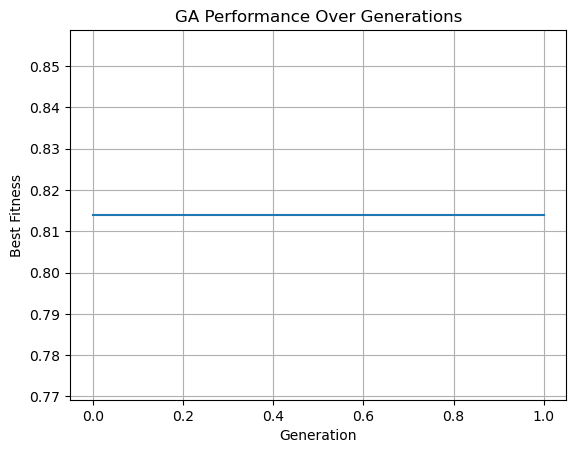


Best Score: 0.8139534883720931

Team 1:
  Jordan Smith (GK), Skill: 88, Cost: 100
  Ethan Howard (DEF), Skill: 80, Cost: 70
  Brayden Hughes (DEF), Skill: 87, Cost: 100
  Connor Hayes (MID), Skill: 89, Cost: 105
  Nathan Wright (MID), Skill: 92, Cost: 120
  Zachary Nelson (FWD), Skill: 86, Cost: 92
  Adrian Collins (FWD), Skill: 85, Cost: 90

Team 2:
  Chris Thompson (GK), Skill: 80, Cost: 80
  Lucas Bennett (DEF), Skill: 85, Cost: 90
  Caleb Fisher (DEF), Skill: 84, Cost: 85
  Ashton Phillips (MID), Skill: 90, Cost: 110
  Bentley Rivera (MID), Skill: 88, Cost: 100
  Chase Murphy (FWD), Skill: 86, Cost: 95
  Elijah Sanders (FWD), Skill: 93, Cost: 140

Team 3:
  Alex Carter (GK), Skill: 85, Cost: 90
  Maxwell Flores (DEF), Skill: 81, Cost: 72
  Daniel Foster (DEF), Skill: 90, Cost: 110
  Gavin Richardson (MID), Skill: 87, Cost: 95
  Hunter Cooper (MID), Skill: 83, Cost: 85
  Landon Powell (FWD), Skill: 89, Cost: 110
  Xavier Bryant (FWD), Skill: 90, Cost: 120

Team 4:
  Ryan Mitchell (

In [331]:
if __name__ == "__main__":
    ga = FootballGA(generations=2, pop_size=20, elite_size=2, selection_method="roulette", elitism=True, pc=0.9, pm=0.05)
    ga.run()
    ga.plot()
    ga.display_best_solution()
